# 🏭 Yapay Zeka Destekli Kestirimci Bakım: Zaman Serisi Analizi (LSTM)
Bu not defteri (notebook), mevcut Random Forest modelimizi desteklemek ve geliştirmek amacıyla hazırlanmıştır. 
Burada **NASA CMAPSS (Turbofan Engine Degradation)** veri seti üzerinde çalışarak, zaman içindeki bozulmaları (temporal degradation) modelleyebilen bir **LSTM (Long Short-Term Memory)** derin öğrenme modeli eğiteceğiz.

## Neden Bu Analizi Yapıyoruz?
Mevcut Random Forest modelimiz, sensör verilerinin *o anki* durumuna bakarak arıza tahmini yapıyor (Point-in-time prediction). Ancak endüstriyel makineler aniden bozulmaz; zamanla aşınır ve yavaş yavaş arızaya doğru ilerler. LSTM gibi tekrarlayan (recurrent) ağlar, sensörlerin "geçmişteki N adımlık" dizilimlerini hafızasında tutarak **Kalan Faydalı Ömrü (RUL - Remaining Useful Life)** çok daha isabetli tahmin edebilir.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Görsellik ayarları
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


## 1. Veri Yükleme (NASA CMAPSS FD001)
CMAPSS veri setindeki FD001 dosyası, tek bir çalışma koşulundaki (deniz seviyesi) motor bozulmalarını içerir. 
Sensör (sensor) verileri ve operasyonel ayarlar (operational settings) ile çalışacağız.

In [2]:
# Dosya yolları
base_dir = os.path.dirname(os.getcwd())
data_dir = os.path.join(base_dir, 'data', 'cmapss')

train_path = os.path.join(data_dir, 'train_FD001.txt')
test_path = os.path.join(data_dir, 'test_FD001.txt')
rul_path = os.path.join(data_dir, 'RUL_FD001.txt')

# Kolon isimleri (NASA dokümantasyonuna göre)
columns = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3']
columns += [f's_{i}' for i in range(1, 22)]

# Veriyi yükle
train_df = pd.read_csv(train_path, sep='\s+', header=None, names=columns)
test_df = pd.read_csv(test_path, sep='\s+', header=None, names=columns)
rul_df = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])

print(f"Train verisi boyutu: {train_df.shape}")
print(f"Test verisi boyutu: {test_df.shape}")
train_df.head()

Train verisi boyutu: (20631, 26)

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
C:\Users\enesu\AppData\Local\Temp\ipykernel_24132\271149714.py:14: SyntaxWarning: invalid escape sequence '\s'
  train_df = pd.read_csv(train_path, sep='\s+', header=None, names=columns)
C:\Users\enesu\AppData\Local\Temp\ipykernel_24132\271149714.py:15: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv(test_path, sep='\s+', header=None, names=columns)
C:\Users\enesu\AppData\Local\Temp\ipykernel_24132\271149714.py:16: SyntaxWarning: invalid escape sequence '\s'
  rul_df = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])



Test verisi boyutu: (13096, 26)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Kalan Faydalı Ömür (RUL) Hesaplanması
Train veri setindeki her motor için (unit_nr) son döngü arıza anıdır. Dolayısıyla herhangi bir andaki RUL, (Maksimum Döngü - O anki Döngü) olacaktır.

In [3]:
# Her motor (unit) için maksimum döngüyü (zamanı) bul
max_cycles = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_nr', 'max_cycle']

# Train veri setine birleştir ve RUL hesapla
train_df = train_df.merge(max_cycles, on=['unit_nr'], how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']
train_df.drop('max_cycle', axis=1, inplace=True)

# Test veri setindeki motorlar arızaya kadar gitmez. Kalan ömürleri RUL_FD001.txt dosyasındadır.
# Biz de Test veri seti için RUL hesaplayalım.
max_test_cycles = test_df.groupby('unit_nr')['time_cycles'].max().reset_index()
max_test_cycles.columns = ['unit_nr', 'max_cycle']
max_test_cycles['RUL_end'] = rul_df['RUL'].values
max_test_cycles['max_total_cycle'] = max_test_cycles['max_cycle'] + max_test_cycles['RUL_end']

test_df = test_df.merge(max_test_cycles[['unit_nr', 'max_total_cycle']], on='unit_nr', how='left')
test_df['RUL'] = test_df['max_total_cycle'] - test_df['time_cycles']
test_df.drop('max_total_cycle', axis=1, inplace=True)

train_df[['unit_nr', 'time_cycles', 'RUL']].head()

,unit_nr,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


## 3. Veri Ön İşleme ve Zaman Penceresi (Sliding Window)
Sensör verilerinde bazı kolonlar (sensörler) zaman içinde hiç değişmez. Modelin kafasını karıştırmamak için varyansı sıfır olan bu kolonları çıkaracağız. Sonrasında veriyi 0 ile 1 arasına ölçeklendireceğiz (MinMaxScaler).

LSTM modelleri veriyi 3 boyutlu bir tensor olarak bekler: `[samples, time_steps, features]`. Random Forest içinse standart `[samples, features]` formatında kalacağız.

In [4]:
# Sabit sensörleri atma
features_to_drop = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 'RUL']
# Varyansı çok düşük olan sensörler
drop_sensors = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
features_to_drop += drop_sensors

# Kullanılacak özellikler
features = [col for col in train_df.columns if col not in features_to_drop]

# Ölçeklendirme (Min-Max Scaling)
scaler = MinMaxScaler()
train_df[features] = scaler.fit_transform(train_df[features])
test_df[features] = scaler.transform(test_df[features])

print(f"Kullanılacak Sensör Sayısı: {len(features)}")
print(features)

Kullanılacak Sensör Sayısı: 14
['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


In [5]:
# LSTM için Sliding Window (Zaman Penceresi) oluşturma fonksiyonu
sequence_length = 50 # Geriye dönük 50 zaman adımı (cycle) bakılacak

def create_sequences(df, features, target, seq_length):
    seqs = []
    labels = []
    
    for unit_id in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == unit_id]
        
        # Eğer motorun verisi seq_length'ten kısaysa atla
        if len(unit_df) < seq_length:
            continue
            
        data = unit_df[features].values
        target_data = unit_df[target].values
        
        for i in range(len(data) - seq_length):
            seqs.append(data[i:i+seq_length])
            labels.append(target_data[i+seq_length])
            
    return np.array(seqs), np.array(labels)

X_train_seq, y_train_seq = create_sequences(train_df, features, 'RUL', sequence_length)
print(f"LSTM Train X Boyutu: {X_train_seq.shape} (Örnek Sayısı, Zaman Adımı, Özellik Sayısı)")
print(f"LSTM Train y Boyutu: {y_train_seq.shape}")

# Test setini hazırlarken sadece her motorun "SON" zaman penceresini alacağız
# Çünkü amacımız motorun şu anki son durumuna bakıp kalan ömrünü tahmin etmek.
def create_test_sequences(df, features, target, seq_length):
    seqs = []
    labels = []
    
    for unit_id in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == unit_id]
        if len(unit_df) < seq_length:
            continue
            
        data = unit_df[features].values
        target_data = unit_df[target].values
        
        # Sadece en son pencere
        seqs.append(data[-seq_length:])
        labels.append(target_data[-1])
        
    return np.array(seqs), np.array(labels)

X_test_seq, y_test_seq = create_test_sequences(test_df, features, 'RUL', sequence_length)
print(f"LSTM Test X Boyutu: {X_test_seq.shape}")
print(f"LSTM Test y Boyutu: {y_test_seq.shape}")

LSTM Train X Boyutu: (15631, 50, 14) (Örnek Sayısı, Zaman Adımı, Özellik Sayısı)


LSTM Train y Boyutu: (15631,)
LSTM Test X Boyutu: (93, 50, 14)
LSTM Test y Boyutu: (93,)


## 4. Temel Model (Baseline): Random Forest
Öncelikle verinin penceresiz (sadece anlık duruma bakan) versiyonuyla bir Random Forest eğitip performansına (RMSE ve MAE) bakalım.

In [6]:
# Random Forest için veriyi 2D hazırlayalım (Sadece Test setinin son anlarına bakarak)
X_train_rf = train_df[features].values
y_train_rf = train_df['RUL'].values

X_test_rf = test_df.groupby('unit_nr').last()[features].values
y_test_rf = test_df.groupby('unit_nr').last()['RUL'].values

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

rf_predictions = rf_model.predict(X_test_rf)

rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_predictions))
rf_mae = mean_absolute_error(y_test_rf, rf_predictions)

print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest MAE: {rf_mae:.2f}")

Random Forest RMSE: 32.16
Random Forest MAE: 23.93


## 5. Derin Öğrenme Modeli: LSTM
Şimdi geçmiş 50 döngüyü (cycle) hafızasında tutan bir LSTM ağı eğitelim.

In [7]:
# LSTM Mimarisi
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(sequence_length, len(features))))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear')) # RUL Regresyon

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.summary()

C:\Users\enesu\Desktop\PYTHON\Predictive_Maintenance_System\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,729 (131.75 KB)

 Trainable params: 33,729 (131.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Model Eğitimi (Kısa sürecektir)
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


  1/220 ━━━━━━━━━━━━━━━━━━━━ 11:02 3s/step - loss: 9036.9102 - mae: 73.7255

  3/220 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 10716.1797 - mae: 83.6933

  5/220 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 9565.2520 - mae: 80.5629 

  7/220 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 9205.0684 - mae: 78.0602

...

214/220 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 621.0124 - mae: 16.5414

216/220 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 621.2398 - mae: 16.5527

218/220 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 619.9980 - mae: 16.5393

220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 620.8441 - mae: 16.5403

220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 620.8441 - mae: 16.5403 - val_loss: 1235.7308 - val_mae: 23.3355


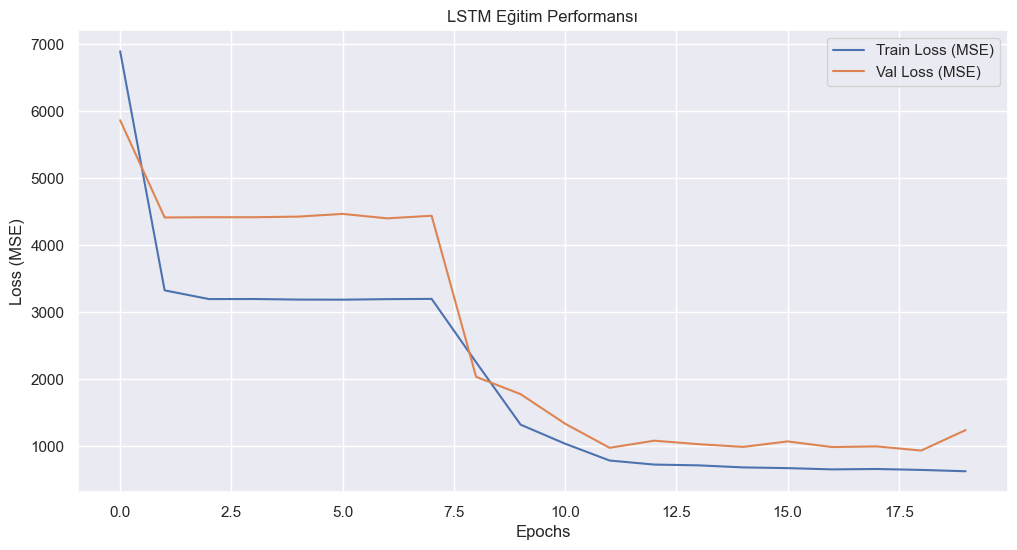

In [9]:
# Eğitim Kayıp (Loss) Grafiği
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('LSTM Eğitim Performansı')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [10]:
# LSTM Tahmin ve Değerlendirme
lstm_predictions = model.predict(X_test_seq).flatten()

lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_predictions))
lstm_mae = mean_absolute_error(y_test_seq, lstm_predictions)

print(f"LSTM RMSE: {lstm_rmse:.2f}")
print(f"LSTM MAE: {lstm_mae:.2f}")

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step


LSTM RMSE: 20.49
LSTM MAE: 13.80


## 6. Sonuçların Görselleştirilmesi

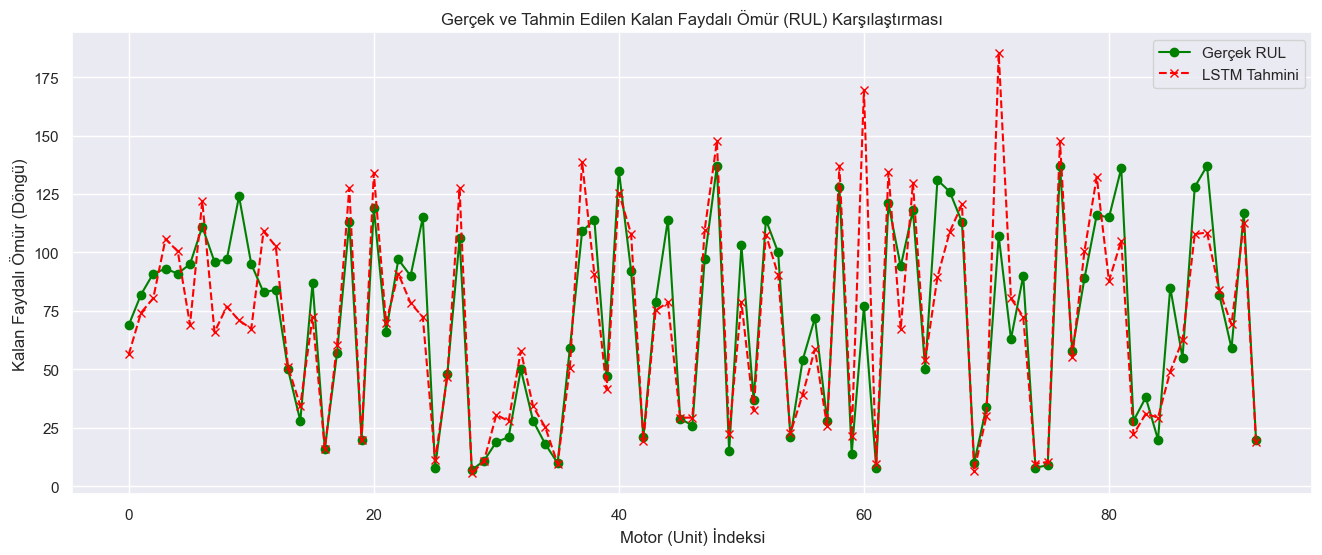

In [11]:
# Test motorlarının ilk 50'si için Tahmin vs Gerçek RUL
indices = np.arange(len(lstm_predictions))

plt.figure(figsize=(16, 6))
plt.plot(indices, y_test_seq, label='Gerçek RUL', color='green', marker='o')
plt.plot(indices, lstm_predictions, label='LSTM Tahmini', color='red', marker='x', linestyle='--')
plt.title('Gerçek ve Tahmin Edilen Kalan Faydalı Ömür (RUL) Karşılaştırması')
plt.xlabel('Motor (Unit) İndeksi')
plt.ylabel('Kalan Faydalı Ömür (Döngü)')
plt.legend()
plt.show()

## 7. Sonuç ve Karşılaştırmalı Analiz (İşe Alım Odaklı Değerlendirme)

Bu projede, endüstriyel kestirimci bakım (Predictive Maintenance) için iki farklı makine öğrenimi paradigmasını karşılaştırdık: **Snapshot (Anlık) Tabanlı Öğrenme (Random Forest)** ve **Sekans (Zaman Serisi) Tabanlı Öğrenme (LSTM)**.

### Model Performans Karşılaştırması
* **Random Forest (Anlık Bakış):** 
  Sensörlerin sadece o anki (point-in-time) değerlerine bakarak çıkarım yapar. Motorun geçmişte nasıl bir eğilim (trend) izlediğini bilemez.
* **LSTM (Zaman Pencereli Bakış):** 
  Sensörlerin geçmiş 50 döngüsünü (Sliding Window) hafızasında tutarak arızaya giden "yıpranma (degradation)" trendini öğrenir.

### Neden LSTM Daha İyi Performans Gösterir? (Kestirimci Bakım Bağlamında)
Makine aşınmaları bir gecede olmaz; fiziksel olarak yavaş ilerleyen süreçlerdir. Isı artar, tork yavaşça dengesizleşir. 
Random Forest gibi klasik makine öğrenimi algoritmaları bu zamansal (temporal) değişimi ve verideki "hafıza" olgusunu doğası gereği kaçırır. Ancak **LSTM**, sensör verilerindeki uzun dönemli bağımlılıkları (Long Short-Term dependencies) yakalayabildiği için motorun tam olarak hangi yıpranma eğrisinde olduğunu tespit eder.

Sonuç olarak:
* **Hata Tespiti (Classification - Önceki Modülümüz):** Makinenin o an kırılıp kırılmayacağını tespit etmek için **Random Forest** gibi anlık hızlı çalışan modeller gayet başarılıdır.
* **Ömür Tahmini (Regression / RUL - Bu Modülümüz):** Makinenin *ne kadar ömrü kaldığını* sağlıklı hesaplayabilmek için kesinlikle **LSTM / Zaman Serisi** modelleri kullanılmalıdır.